In [77]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, MultiPoint
import folium
from folium.plugins import TimestampedGeoJson
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_feather("/home/perann/Bureau/MVA/Interactions/interactions/data/wildfire_data.feather")

# **I. Ignition dataset**

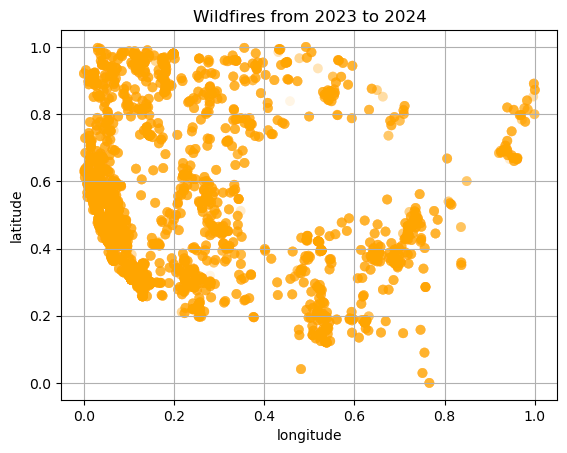

In [7]:
def plot_historic_wildfire(df: pd.DataFrame, start_date, end_date ) -> None:
    
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)


    (df[(df.datetime >= start_date) & (df.datetime <= end_date) & (df.wildfire == "Yes")][["longitude", "latitude"]]
        .assign(
            longitude = lambda df_: (df_.longitude - df_.longitude.min()) / (df_.longitude.max() - df_.longitude.min()),
            latitude = lambda df_: (df_.latitude - df_.latitude.min()) / (df_.latitude.max() - df_.latitude.min())
        )
        .plot.scatter(
            x="longitude",
            y="latitude", 
            grid=True, 
            title=f"Wildfires from {start_date.year} to {end_date.year}",
            alpha=0.1,           
            s=50,                
            c="orange",      
            edgecolors='none'
        )
    )


plot_historic_wildfire(df, "2023-06-01", "2024-01-01")

In [8]:
df.columns

Index(['latitude', 'longitude', 'datetime', 'wildfire', 'pr', 'rmax', 'rmin',
       'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc',
       'etr', 'pet', 'vpd'],
      dtype='str')

# **II. Firespreading dataset**

In [8]:
df_raw = pd.read_csv("/home/perann/Bureau/MVA/Interactions/interactions/data/wildfiredb.csv", nrows = 10)

for col in df_raw.columns:
    print(col)

Polygon_ID
acq_date
frp
Neighbour
Neighbour_frp
CBC2014_max
CBC2014_min
CBC2014_median
CBC2014_sum
CBC2014_mode
CBC2014_count
CBC2014_mean
CBD2012_max
CBD2012_min
CBD2012_median
CBD2012_sum
CBD2012_mode
CBD2012_count
CBD2012_mean
CBD2016_max
CBD2016_min
CBD2016_median
CBD2016_sum
CBD2016_mode
CBD2016_count
CBD2016_mean
CBH2012_max
CBH2012_min
CBH2012_median
CBH2012_sum
CBH2012_mode
CBH2012_count
CBH2012_mean
CBH2014_max
CBH2014_min
CBH2014_median
CBH2014_sum
CBH2014_mode
CBH2014_count
CBH2014_mean
CBH2016_max
CBH2016_min
CBH2016_median
CBH2016_sum
CBH2016_mode
CBH2016_count
CBH2016_mean
CC2012_max
CC2012_min
CC2012_median
CC2012_sum
CC2012_mode
CC2012_count
CC2012_mean
CC2014_max
CC2014_min
CC2014_median
CC2014_sum
CC2014_mode
CC2014_count
CC2014_mean
CC2016_max
CC2016_min
CC2016_median
CC2016_sum
CC2016_mode
CC2016_count
CC2016_mean
CH2012_max
CH2012_min
CH2012_median
CH2012_sum
CH2012_mode
CH2012_count
CH2012_mean
CH2014_max
CH2014_min
CH2014_median
CH2014_sum
CH2014_mode
CH2014_coun

1. Identifiants et Intensité

- Polygon_ID : L'identifiant unique du pixel (de 375m x 375m).

- acq_date : Date de détection du feu par le satellite.

- frp : Intensité de la chaleur (Fire Radiative Power) au centre.

- Neighbour / Neighbour_frp : Identifiant et intensité des feux dans les pixels adjacents (indique la propagation).

2. Topographie (L'essentiel pour la vitesse)

- ELEV (Elevation) : Altitude du terrain.

- SLP (Slope) : Pente du terrain (exprimée en degrés ou %). Plus elle est élevée, plus le feu monte vite.

- Aspect (non listé mais souvent lié) : L'orientation (Nord/Sud) qui joue sur la sécheresse du bois.

3. Structure de la Forêt (Le combustible)

Ces colonnes décrivent la "disponibilité" du bois pour brûler :

- CC (Canopy Cover) : Pourcentage de couverture du sol par les cimes.

- CH (Canopy Height) : Hauteur moyenne des arbres.

- CBH (Canopy Base Height) : Distance entre le sol et les premières branches. Crucial : si c'est bas, le feu de sol devient un feu de cime.

- CBD (Canopy Bulk Density) : Densité de la biomasse dans la canopée (le "carburant" disponible en haut).

4. Type de Végétation

- EVT / FVT (Existing/Fuel Vegetation Type) : Classification biologique (ex: chênes, herbes sèches, sapins).

- EVC / FVC (Vegetation Cover) : Densité de la couche de végétation vivante.

- EVH / FVH (Vegetation Height) : Hauteur de la couche de végétation.

5. Signification des Suffixes (Statistiques)

Chaque variable (ex: SLP2016) est déclinée en plusieurs mesures sur le pixel :

- _max / _min : Valeurs extrêmes sur la zone.

- _mean / _median : Valeurs moyennes (les plus stables pour ton analyse).

- _count : Nombre de points de mesure dans le polygone.

# **III. Map projection**

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
shapefile_path = "/home/perann/Bureau/MVA/Interactions/interactions/data/effis_layer/modis.ba.poly.shp"


fire_data = gpd.read_file(shapefile_path)
fire_data.head()

,id,FIREDATE,FINALDATE,LASTUPDATE,COUNTRY,PROVINCE,COMMUNE,AREA_HA,BROADLEA,CONIFER,MIXED,SCLEROPH,TRANSIT,OTHERNATLC,AGRIAREAS,ARTIFSURF,OTHERLC,PERCNA2K,CLASS,geometry
0,2,2016-08-28 00:00:00,2016-08-28 00:00:00,2022-01-26 11:57:54.973474,AL,Korcë,Konispol,67,0,0,0,19.402985074597908,16.417910447736688,10.447761194014257,53.731343283501886,0,0,0,FireSeason,"POLYGON ((20.18901 39.74908, 20.18909 39.75006..."
1,888,2016-08-08 00:00:00,2016-08-15 00:00:00,2022-01-26 11:57:54.973474,PT,Área Metropolitana do Porto,Covelo de Paivó e Janarde,26593,0.6020922706404734,0.2558892150222012,0.2220215247986746,0,56.893956498833234,38.661849928501404,3.2174305712350297,0.14675999096861542,0,9.843358251326316,FireSeason,"POLYGON ((-8.06251 40.84474, -8.06033 40.8436,..."
2,19,2016-08-11 00:00:00,2016-08-12 00:00:00,2022-01-26 11:57:54.973474,PT,Tâmega e Sousa,Caçarilhe e Infesta,81,0,1.17647058823391,0,0,67.05882352933287,19.99999999997647,11.7647058823391,0,0,0,FireSeason,"POLYGON ((-8.05657 41.40623, -8.05945 41.4048,..."
3,87,2016-07-27 00:00:00,2016-07-28 00:00:00,2022-01-26 11:57:54.973474,TR,??rnak,N.A.,72,0,0,0,0,70.83333333323495,22.222222222191355,0,6.9444444444348,0,0,FireSeason,"POLYGON ((42.50247 37.53773, 42.5029 37.53451,..."
4,368,2016-08-24 00:00:00,2016-08-25 00:00:00,2022-01-26 11:57:54.973474,IT,Genova,Bogliasco,267,11.654135338341485,5.639097744358783,0.37593984962391885,0,7.894736842102295,74.06015037591202,0.37593984962391885,0,0,5.453094633641743,FireSeason,"POLYGON ((9.06157 44.39255, 9.06266 44.39417, ..."


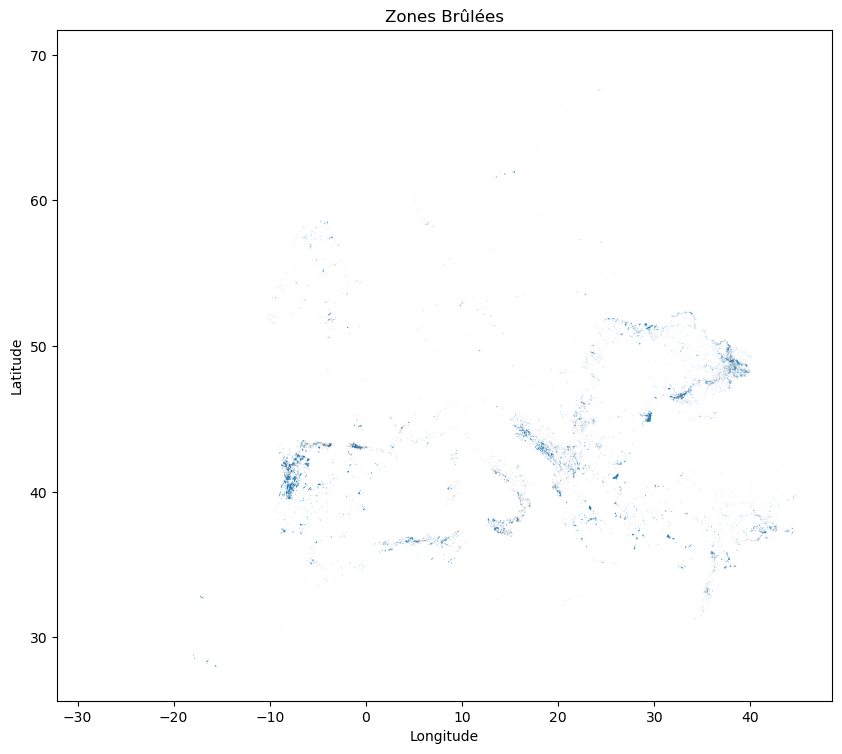

In [56]:
fire_data.plot(figsize=(10, 10))
plt.title("Zones Brûlées")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [87]:
fire_data = (fire_data.set_index("id")
.rename(columns = lambda x : x.lower())
.astype({"class" : "category",
        "area_ha": "float32",
        "broadlea" : "float32",
        "conifer" : "float32",
        "mixed" : "float32",
        "scleroph" : "float32",
        "transit": "float32",
        "othernatlc" : "float32",
        "agriareas" : "float32",
        "artifsurf" : "float32",
        "otherlc" : "float32",
        "percna2k": "float32"})
.assign(firedate = lambda df_ : pd.to_datetime(df_.firedate, format = "mixed"),
        finaldate = lambda df_:  pd.to_datetime(df_.finaldate, format  = "mixed"),
        lastupdate = lambda df_ : pd.to_datetime(df_.lastupdate, format = "mixed")))

In [96]:
fire_data.sort_values("finaldate")

,firedate,finaldate,lastupdate,country,province,commune,area_ha,broadlea,conifer,mixed,scleroph,transit,othernatlc,agriareas,artifsurf,otherlc,percna2k,class,geometry
id,,,,,,,,,,,,,,,,,,,
10264,2016-02-07 00:00:00,2016-02-08 00:00:00,2022-01-26 11:57:54.973474,RO,Tulcea,Sfântu Gheorghe,1446.0,0.0,0.0,0.000000,0.0,0.0,100.0,0.000000,0.0,0.0,100.0,FireSeason,"POLYGON ((29.49121 44.84792, 29.48828 44.84693..."
10410,2016-02-10 00:00:00,2016-02-10 00:00:00,2022-01-26 11:57:54.973474,RO,Tulcea,Cri?an,228.0,0.0,0.0,0.000000,0.0,0.0,100.0,0.000000,0.0,0.0,100.0,FireSeason,"POLYGON ((29.36056 45.1332, 29.36271 45.13849,..."
10236,2016-02-14 00:00:00,2016-02-14 00:00:00,2022-01-26 11:57:54.973474,RO,Tulcea,Ora? Sulina,598.0,0.0,0.0,0.000000,0.0,0.0,100.0,0.000000,0.0,0.0,100.0,FireSeason,"POLYGON ((29.59543 45.15603, 29.59578 45.15698..."
1254,2016-02-15 00:00:00,2016-02-17 00:00:00,2022-01-26 11:57:54.973474,RO,Tulcea,C.A. Rosetti,734.0,0.0,0.0,0.000000,0.0,0.0,100.0,0.000000,0.0,0.0,100.0,FireSeason,"POLYGON ((29.47708 45.25911, 29.47886 45.25481..."
27,2016-02-17 00:00:00,2016-02-18 00:00:00,2022-01-26 11:57:54.973474,RO,Tulcea,C.A. Rosetti,372.0,0.0,0.0,0.000000,0.0,0.0,100.0,0.000000,0.0,0.0,100.0,FireSeason,"POLYGON ((29.50661 45.23464, 29.50686 45.23532..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294903,2026-04-11 02:26:00,2026-04-11 02:26:00,2026-04-13 07:45:58.981831,ES,Asturias,Tineo,11.0,20.0,0.0,0.000000,0.0,0.0,80.0,0.000000,0.0,0.0,0.0,7DAYS,"POLYGON ((-6.38931 43.38388, -6.38926 43.38379..."
294902,2026-04-11 02:26:00,2026-04-11 02:26:00,2026-04-13 07:45:58.981831,ES,Asturias,Tineo,10.0,0.0,0.0,0.000000,0.0,0.0,90.0,10.000000,0.0,0.0,0.0,7DAYS,"POLYGON ((-6.38639 43.38593, -6.38624 43.38584..."
294924,2026-04-11 10:58:00,2026-04-11 12:38:00,2026-04-13 08:04:27.517171,IT,Salerno,Rofrano,1.0,100.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,100.0,7DAYS,"POLYGON ((15.40292 40.1939, 15.40297 40.19361,..."


## **IV. Essai numero 4000**

In [67]:
df_raw = gpd.read_file("/home/perann/Bureau/MVA/Interactions/interactions/data/FireSpread_MedEU/FireSpread_MedEU.shp")

df = (df_raw.rename(columns = lambda x : x.lower().replace(" ", "_").replace("(", "").replace(")",""))
.sort_values(["effis_id", "prop_step"])
.assign(acqu_date = lambda df_ : pd.to_datetime(df_.acqu_date, format = "mixed"),
        ba_ha = lambda df_ : df_.ba_ha.fillna(0),
        quality = lambda df_ : df_.quality.astype("category"))
.drop(columns = "info"))

relevant_indices  = df.effis_id.unique()
effis_data = "/home/perann/Bureau/MVA/Interactions/interactions/data/effis_layer/modis.ba.poly.shp"
effis_data = gpd.read_file(effis_data)

geo_data = (effis_data[["id","FIREDATE", "FINALDATE","COUNTRY",	"PROVINCE","COMMUNE","AREA_HA"]]
            .astype({"id" : "int32"})
            .query("id in @relevant_indices")
            .set_index("id")
            .rename(columns= lambda x : x.lower()))


df = (df.merge(geo_data, how = "left", left_on = "effis_id", right_index = True)
        .dropna())

df = df[(df.country != "N.A.") & (df.province != "N.A.") & (df.commune != "N.A.")]


In [40]:
df[["country", "province", "commune"]].drop_duplicates().values

array([['IT', 'Cosenza', 'Rose'],
       ['IT', 'Messina', 'Scaletta Zanclea'],
       ['IT', 'Crotone', 'Cutro'],
       ['AL', 'Lezhë', 'Bulqizë'],
       ['IT', 'Siracusa', 'Siracusa'],
       ['IT', 'Potenza', 'Viggianello'],
       ['MK', '???????', 'Brvenica'],
       ['PT', 'Douro', 'Freixo de Numão'],
       ['IT', 'Siracusa', 'Avola'],
       ['FR', 'Var', 'Esparron'],
       ['IT', 'Palermo', 'Corleone'],
       ['IT', 'Reggio di Calabria', 'Camini'],
       ['IT', 'Agrigento', 'Casteltermini'],
       ['IT', 'Cosenza', 'Civita'],
       ['IT', 'Catania', 'San Michele di Ganzaria'],
       ['IT', 'Benevento', 'Durazzano'],
       ['IT', 'Caltanissetta', 'Butera'],
       ['PT', 'Algarve', 'Barão de São Miguel'],
       ['IT', 'Enna', 'Aidone'],
       ['IT', 'Agrigento', 'Santa Elisabetta'],
       ['AL', 'Korcë', 'Himarë'],
       ['AL', 'Tiranë', 'Rrogozhinë'],
       ['IT', 'Enna', 'Regalbuto'],
       ['IT', 'Palermo', 'Prizzi'],
       ['IT', 'Cosenza', 'Acri'],
       [

Pays,Région / Province,Ville / Commune,Latitude,Longitude
IT,Cosenza,Rose,39.400,16.288
IT,Messina,Scaletta Zanclea,38.046,15.462
IT,Crotone,Cutro,39.034,16.983
AL,Lezhë,Bulqizë,41.493,20.221
IT,Siracusa,Siracusa,37.075,15.286
IT,Potenza,Viggianello,39.974,16.088
PT,Douro,Freixo de Numão,41.066,-7.218
IT,Siracusa,Avola,36.908,15.132
FR,Var,Esparron,43.591,5.848
IT,Palermo,Corleone,37.813,13.301
IT,Reggio di Calabria,Camini,38.435,16.486
IT,Agrigento,Casteltermini,37.541,13.645
IT,Cosenza,Civita,39.827,16.313
IT,Catania,San Michele di Ganzaria,37.282,14.427
IT,Benevento,Durazzano,41.062,14.451
IT,Caltanissetta,Butera,37.186,14.185
PT,Algarve,Barão de São Miguel,37.118,-8.790
IT,Enna,Aidone,37.441,14.446
IT,Agrigento,Santa Elisabetta,37.436,13.557
AL,Korcë,Himarë,40.101,19.744
AL,Tiranë,Rrogozhinë,41.077,19.665
IT,Enna,Regalbuto,37.649,14.637
IT,Palermo,Prizzi,37.721,13.431
IT,Cosenza,Acri,39.491,16.383
AL,Vlorë,Gjirokastër,40.075,20.138
ES,Barcelona,Bellprat,41.518,1.419
IT,Reggio di Calabria,Mammola,38.364,16.238
IT,Reggio di Calabria,Caulonia,38.380,16.409
IT,Reggio di Calabria,Bivongi,38.480,16.452
IT,Reggio di Calabria,San Luca,38.148,16.065
IT,Palermo,Scillato,37.857,13.905
IT,Messina,Francavilla di Sicilia,37.902,15.136
IT,Cosenza,Belvedere Marittimo,39.619,15.862
IT,Vibo Valentia,Pizzoni,38.622,16.248
IT,Ragusa,Ragusa,36.926,14.726
ES,Salamanca,San Felices de los Gallegos,40.850,-6.708
IT,Palermo,Lercara Friddi,37.747,13.603
ES,Málaga,Júzcar,36.625,-5.170
ES,Navarra,San Martín de Unx,42.506,-1.561
FR,Var,Aiguines,43.775,6.243
PT,Douro,Linhares,41.222,-7.361
FR,Gironde,Teste-de-Buch,44.630,-1.149
ES,Málaga,Alhaurín de la Torre,36.662,-4.561
IT,Crotone,Isola di Capo Rizzuto,38.959,17.094
IT,Matera,Pisticci,40.392,16.551
IT,Salerno,Vibonati,40.063,15.589
PT,Douro,Adoufe e Vilarinho de Samardã,41.328,-7.756
PT,Alto Tâmega,Alvadia,41.350,-7.822
IT,Caltanissetta,Campofranco,37.510,13.608

<Axes: >

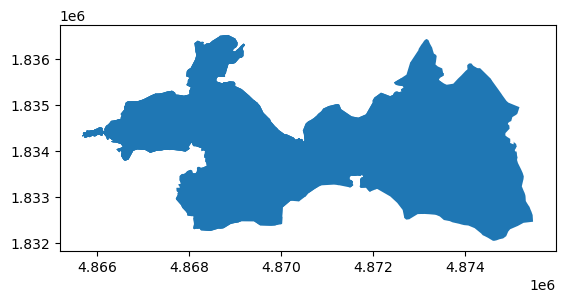

In [ ]:
df[df.effis_id == 593].plot()

In [74]:
ex = df[df.effis_id == 593]


In [75]:
ex

,effis_id,prop_step,acqu_date,acqu_time,ba_ha,quality,clouds,smoke,crop,crop/veg,...,urban,bare,grassland,geometry,firedate,finaldate,country,province,commune,area_ha
0,593,0.0,2017-08-02,08:57:28,0.00,very high,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,"POLYGON ((4866497.283 1834508.364, 4866497.278...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
1,593,1.0,2017-08-03,08:58:31,26.18,high,0.0,0.0,8.0,0.0,...,0.0,0.0,0.0,"POLYGON ((4866610.166 1834224.134, 4866607.518...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
2,593,2.0,2017-08-03,13:22:03,104.15,medium,0.0,3.0,12.0,18.0,...,0.0,0.0,0.0,"POLYGON ((4867327.145 1834013.048, 4867324.135...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
3,593,3.0,2017-08-04,08:56:22,377.04,medium,0.0,2.0,19.0,19.0,...,0.0,0.0,0.0,"POLYGON ((4868378.623 1834016.429, 4868362.851...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
5,593,4.0,2017-08-06,08:58:20,1067.04,high,0.0,1.0,16.0,12.0,...,0.0,0.0,1.0,"POLYGON ((4868101.674 1832356.242, 4868118.783...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
7,593,5.0,2017-08-08,09:01:43,1519.23,medium,0.0,1.0,14.0,11.0,...,0.0,0.0,1.0,"POLYGON ((4868097.493 1832327.623, 4868110.298...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251
10,593,6.0,2017-08-11,09:55:16,2138.90,high,0.0,1.0,10.0,9.0,...,0.0,0.0,1.0,"POLYGON ((4868097.855 1832321.664, 4868097.493...",2017-08-03 00:00:00,2017-08-08 00:00:00,IT,Cosenza,Rose,1251


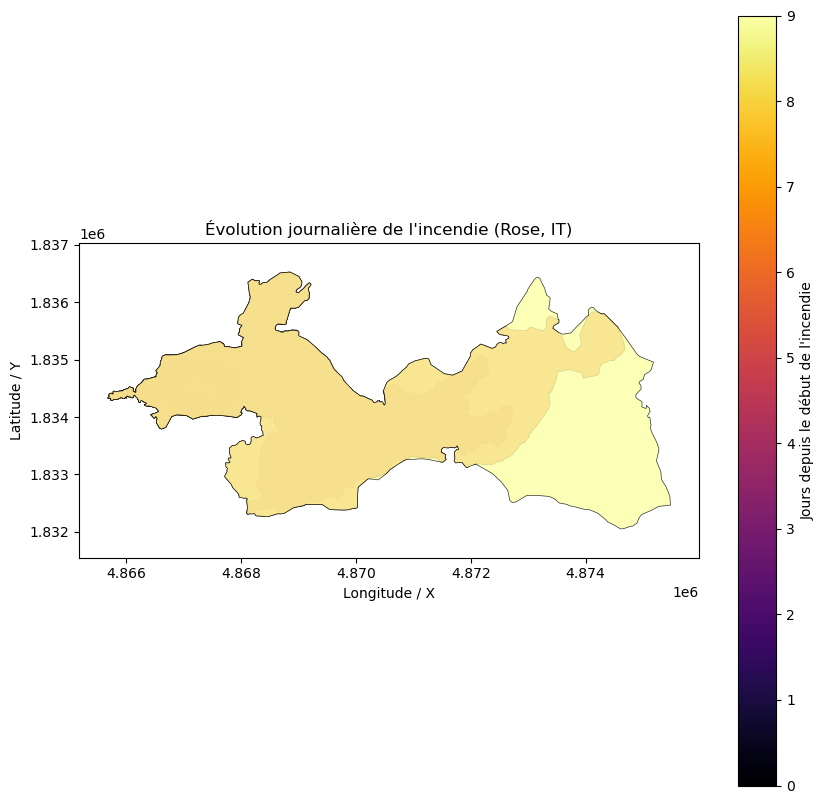

In [84]:
import matplotlib.pyplot as plt

ex = ex.sort_values('acqu_date')

ex['date_rank'] = (ex['acqu_date'] - ex['acqu_date'].min()).dt.days

fig, ax = plt.subplots(figsize=(10, 10))

ex.plot(column='date_rank', 
        cmap='inferno', 
        ax=ax, 
        legend=True, 
        edgecolor='black', 
        linewidth=0.5, 
        alpha=0.8,
        legend_kwds={'label': "Jours depuis le début de l'incendie"})


minx, miny, maxx, maxy = ex.total_bounds

margin = 500 
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

plt.title("Évolution journalière de l'incendie (Rose, IT)")
plt.xlabel("Longitude / X")
plt.ylabel("Latitude / Y")

plt.show()

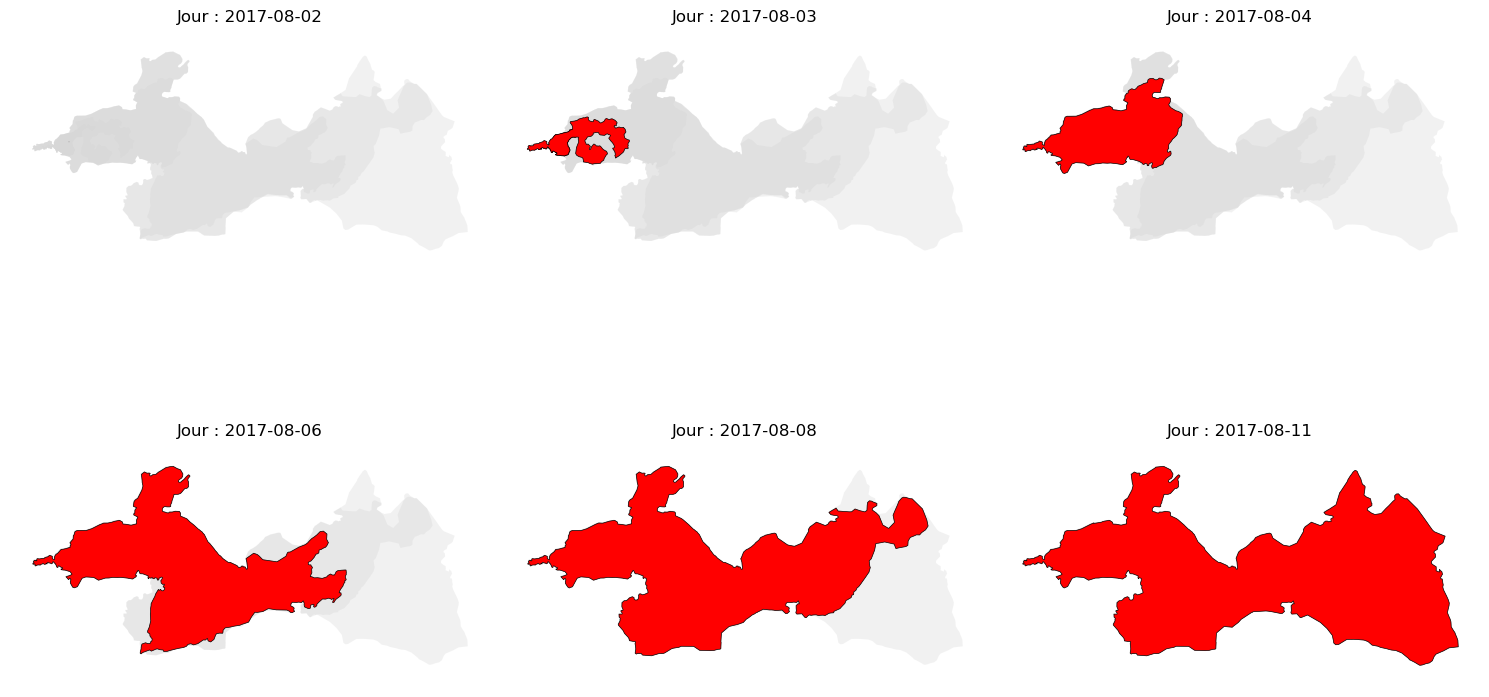

In [86]:
import matplotlib.pyplot as plt
import math

dates = sorted(ex['acqu_date'].unique())
n_plots = len(dates)
n_cols = 3  
n_rows = math.ceil(n_plots / n_cols)

minx, miny, maxx, maxy = ex.total_bounds
margin = 500

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5), sharex=True, sharey=True)
axes = axes.flatten() 

for i, date in enumerate(dates):
    ax = axes[i]
    
    ex.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.3)
    
    day_data = ex[ex['acqu_date'] == date]
    day_data.plot(ax=ax, color='red', edgecolor='black', linewidth=0.5)
    
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)
    
    ax.set_title(f"Jour : {date.strftime('%Y-%m-%d')}")
    ax.set_axis_off() 


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()